In [7]:
import warnings
# warnings.filterwarnings('ignore',category=DeprecationWarning)
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import pickle

#nlp
# import nltk
from wordcloud import WordCloud
import spacy

#topic modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# spacy english model, 'sm' is the small, fast model -ideal for classroom use
nlp = spacy.load("en_core_web_sm")

In [9]:
raw_documents = [
    # Technology
    "The new smartphone model has an amazing high-definition camera.",
    "Data privacy is a huge concern in modern social media apps.",
    "Artificial intelligence is changing the way software is developed.",
    "Quantum computing might revolutionize the entire technological landscape.",
    "The system is connecting to the server while other devices connect automatically.",
    "Stable connections are vital, but his connection remained very weak.",
    "The programmer is programming a new application for mobile users.",
    "Recommendation engines use your browsing history to suggest products and content.",
    "Supercomputers compute complex data faster than a regular computer can.",
    "There are certainly elements like artificial intelligence that have expanded how we use our smartphones.",
    "Software engineers apply engineering principles and knowledge of programming languages to build software solutions for end users.",
    "Artificial intelligence is the simulation of human intelligence in machines that are programmed to think like humans and mimic their actions.",
    "Strong encryption is the backbone of modern cybersecurity protocols.",
    "GPS navigation helps users navigate even when they are navigating difficult terrain.",
    "The navigator signaled that the navigation system was finally navigated correctly.",
    "5G networks promise faster download speeds and lower latency for mobile users.",
    "The smartphone combined technologies that once required multiple separate devices.",
    "Battery optimization technology extends usage time between charges.",
    "Algorithms determine what content users see, creating personalized but filtered realities.",
    "My phone automatically organized all my photos by face and location.",
 
    # Cooking
    "Olive oil is an all-purpose oil used in regular daily cooking",
    "The secret ingredient in my grandmother's cake recipe is nutmeg.",
    "Stir-frying is one of the quickest and easiest cooking methods, and it works great with vegetables, proteins, and even starches like potatoes.",
    "Baking ingredients are used for baking, although they can also be used for cooking sometimes."
    "Prepare the ingredients like onions and garlic before starting the stir-fry.",
    "The smoked variety imparts a deep, smoky flavor to roasted vegetables, meats, and stews.",
    "The chef fried the fish until it was perfectly fried and crispy.",
    "When you are baking, remember that baked goods continue baking after leaving the oven.",
    "She seasoned the meat after seasoning the vegetables with salt.",
    "The recipe calls for three different seasonings and spices.",
    "Maybe you like your garlic flavor a little stronger, in which case you can add two or three cloves, or perhaps you might want to use olive oil instead of butter when you sauté something to give the dish a lighter, healthier tone.",
    "A small amount of oil is used in a hot pan at medium-high heat to cook the food, resulting in a golden, usually crisp exterior that locks in moisture.",
    "If you are whisksing by hand, your arm might get tired quite quickly.",
    "The restaurant specializes in poached eggs served with a side of hollandaise.",
    "Plain flour is essential in baking, thickening sauces, and giving food crusts",
    "They had poached several salmon fillets before the dinner rush started.",
    "Seasoning and a light coating of oil help boost crispness and enhance taste.",
    "Marinating beforehand enhances tenderness and taste, whereas grill marks give food a distinctive, appetizing look.",
    "For vegetables, avoid overboiling to preserve color and nutrients, and try using a lid to bring water to a boil faster."
 
    # Politics
    "The prime minister addressed the parliament regarding the new trade agreement.",
    "Voters must consider all aspects of the referendum before casting a ballot.",
    "The government announced a significant decrease in environmental taxes.",
    "Local councils are meeting to discuss urban development plans.",
    "Citizens are voting in the local mayoral election today.",
    "High energy prices have been a consistent theme in discussions among leaders for months",
    "The government published a white paper policy document this Monday.",
    "Good governance is required for any governor to be successful.",
    "The committee elected a leader after the previous elections were voided.",
    "An elective body manages how the electoral process is handled.",
    "The legislative body is debating the merits of the proposed healthcare bill.",
    "A peaceful protest can be a powerful tool for driving social change.",
    "The protestor was arrested while protesting alongside other determined protestors.",
    "A bill is a draft of a new law or a change to an existing law, presented to Parliament.",
    "Following the Cabinet's approval, the Department of Justice drafts a bill.",
    "To participate in political elections, you must be registered to vote.",
    "Political analysts suggest that the recent policy shift could influence the upcoming election results.",
    "Public opinion polls indicate a significant generational divide on climate change policies.",
    "The opposition party criticized the administration's handling of the economic crisis.",
    "The rise of populist movements across Europe reflects growing public dissatisfaction with traditional parties.",
]
 
print(f"Loaded a corpus of {len(raw_documents)} documents.")
print(f"Example raw text :\n {raw_documents[8]}")

Loaded a corpus of 57 documents.
Example raw text :
 Supercomputers compute complex data faster than a regular computer can.


## 2.Preprocessing the texts

In [ ]:
# Scenario 1: Raw (minimal cleaning)
def preprocess_raw(text):
    return text.lower()
# Scenation 2: No Lemma (Stopwords removed only):
def preprocess_no_lemma(text):
    doc = nlp(text=text)
    return " ".join([t.lower_ for t in doc if not t.is_stop and t.is_alpha])

#Scenario 3 Full spaCy (lemmatization + stopwords removal)
# We use a list comprehension to:
# - Lowercase (token.lemma_.lower())
# - Remove Stop Words (token.is_stop)
# - Remove Punctuation (token.is_alpha)
# - Extract the Lemma (token.lemma_)

def preprocess_cleaned(text) :
    doc = nlp(text=text)
    return " ".join([t.lemma_.lower() for t in doc if not t.is_stop and t.is_alpha])

#Scenario 4 : Keep only the NOUNS
def preprocess_nouns_only(text):
    doc = nlp(text=text)
    #Only keep nouns, these are usually the "Topics"
    return " ".join([t.lemma_.lower() for t in doc if t.pos_ == "NOUN" and not t.is_stop])
    
    
# Apply to our data
data_raw = [preprocess_raw(d) for d in raw_documents]
data_no_lemma = [preprocess_no_lemma(d) for d in raw_documents]
data_cleaned = [preprocess_cleaned(d) for d in raw_documents]
data_nouns = [preprocess_nouns_only(d) for d in raw_documents]


'certainly elements like artificial intelligence expanded use smartphones'

In [25]:
index_to_show = 15
print (f" ---- Comparison of Pre-processing (Doc {index_to_show}) ---- ")
print(f"Raw : {data_raw[index_to_show]}")
print(f"No Lemma : {data_no_lemma[index_to_show]}")
print(f"Cleaned : {data_cleaned[index_to_show]}")
print(f"Nouns : {data_nouns[index_to_show]}")

 ---- Comparison of Pre-processing (Doc 15) ---- 
Raw : 5g networks promise faster download speeds and lower latency for mobile users.
No Lemma : g networks promise faster download speeds lower latency mobile users
Cleaned : g network promise fast download speed low latency mobile user
Nouns : g network download speed latency user


## 3. Topic Modeling and LDA

In [ ]:
def run_lda_and_plot(data, title, save_model=False, model_name = None):
    # 1. Vectorize (convert text to numbers)
    vectorizer = CountVectorizer(max_features=1000)
    tf = vectorizer.fit_transform(data)         # convertit les textes en une matrice de fréquences (Bag Of Words)
    words = vectorizer.get_feature_names_out()
    
    # 2. fit LDA Model (finding 3 topics)
    lda = LatentDirichletAllocation(n_components=3, max_iter=10, random_state=42)
    lda.fit(tf)
    
    # 3. Plotting Word Clouds
    fig, axes = plt.subplots(1,3, figsize =(15,5))
    fig.suptitle(title, fontsize = 16, fontweight ='bold')
    
    for topic_idx, topic in enumerate(lda.components_):
        # create a dictionary of word frequencies for the cloud
        word_freq = {words[i]: topic[i] for i in topic.argsort()[:-20 -1: -1]} #pour chaque topic on récupère les 20 mots les + importants
        
        wc = WordCloud(background_color='white', colormap='tab10').generate_from_frequencies(word_freq) #génère le WC, les mots les plus fréquents sont en plus grand
        
        axes[topic_idx].imshow(wc, interpolation = 'bilinear')
        axes[topic_idx].set_title(f"Topic {topic_idx}")
        axes[topic_idx].axis("off")
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    if save_model and model_name:
        with open(f"{model_name}_lda.pkl", "wb") as f:
            pickle.dump(lda,f)
        with open(f"{model_name}_vectorizer.pkl", "wb") as f:
            pickle.dump(vectorizer,f)
        print(f"Models saved as {model_name}_lda.pkl and {model_name}_vectorizer.pkl")
        
    return lda, vectorizer

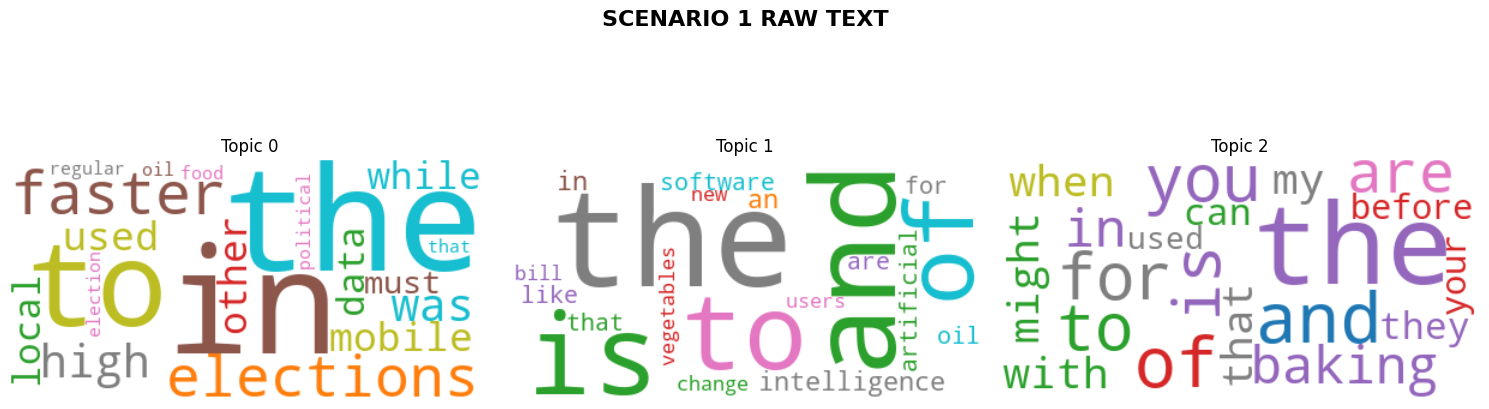

Models saved as raw_lda.pkl and raw_vectorizer.pkl


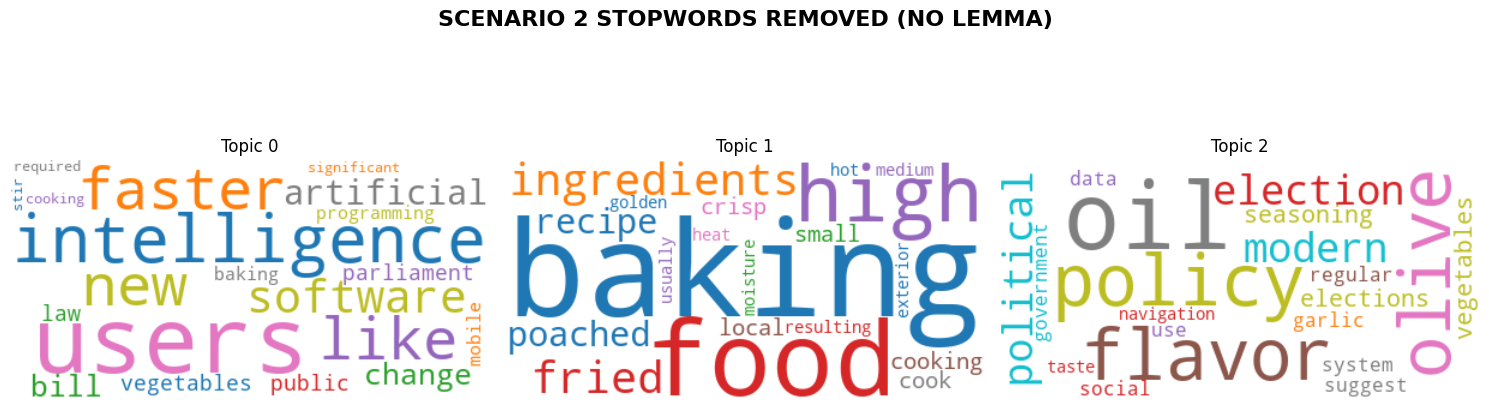

Models saved as no_lemma_lda.pkl and no_lemma_vectorizer.pkl


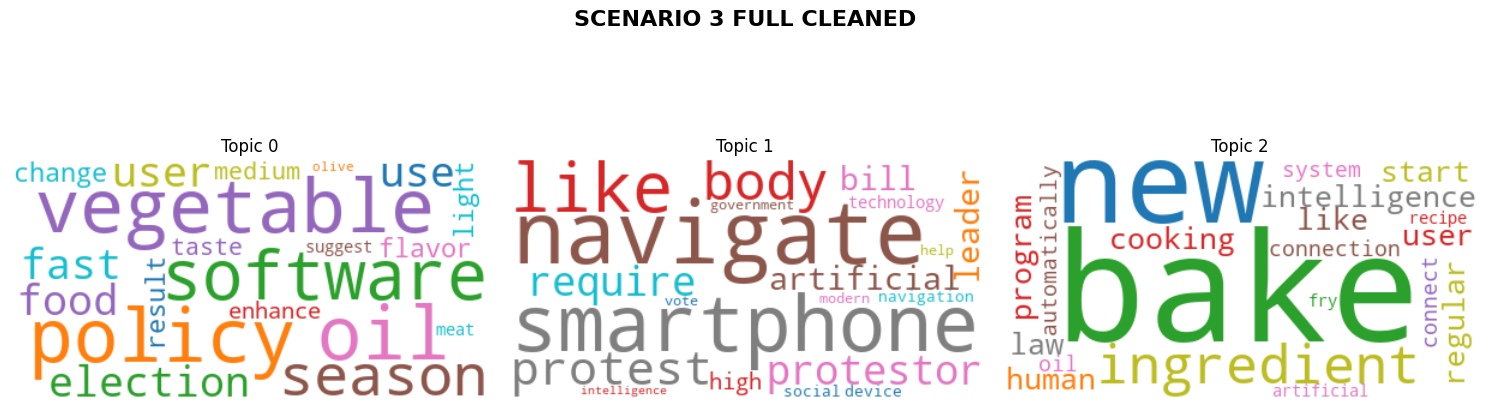

Models saved as cleaned_lda.pkl and cleaned_vectorizer.pkl


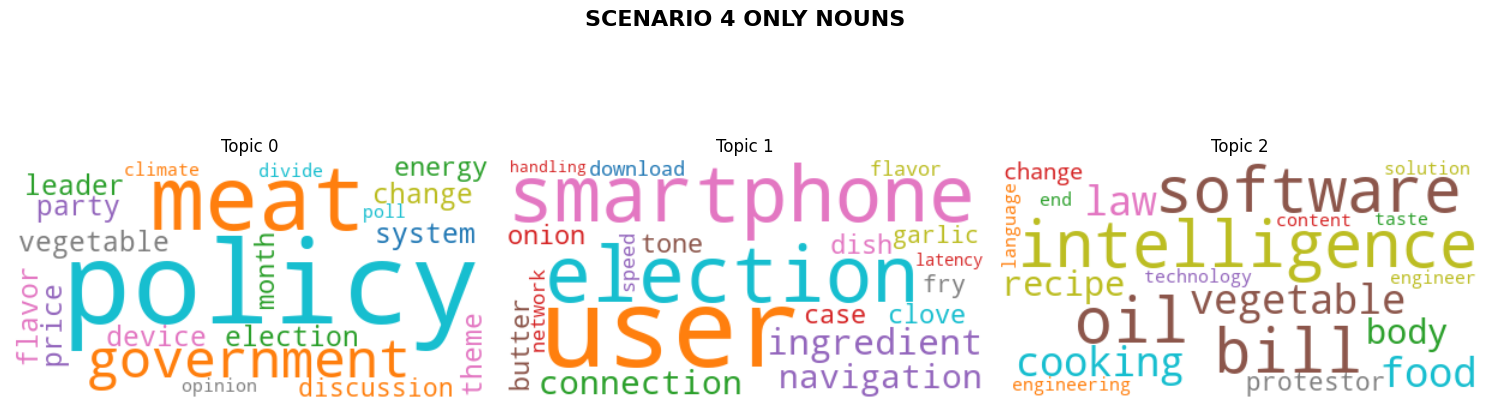

Models saved as nouns_lda.pkl and nouns_vectorizer.pkl


In [33]:
# Train and save all models (run this once)
lda_raw, vectorizer_raw = run_lda_and_plot(data_raw, "SCENARIO 1 RAW TEXT", save_model=True, model_name="raw")
lda_no_lemma, vectorizer_no_lemma = run_lda_and_plot(data_no_lemma, "SCENARIO 2 STOPWORDS REMOVED (NO LEMMA)", save_model=True, model_name="no_lemma")
lda_cleaned, vectorizer_cleaned = run_lda_and_plot(data_cleaned, "SCENARIO 3 FULL CLEANED", save_model=True, model_name="cleaned")
lda_nouns, vectorizer_nouns = run_lda_and_plot(data_nouns, "SCENARIO 4 ONLY NOUNS", save_model=True, model_name="nouns")

## 4. Simple prediction using our models

In [38]:
# Create functions to predict new sentence
 
def load_lda_model(model_name):
    """
    Load a saved LDA model and its vectorizer.
    
    Args:
        model_name: 'raw', 'no_lemma', 'cleaned', or 'nouns'
    
    Returns:
        lda_model, vectorizer
    """
    with open(f'{model_name}_lda.pkl', 'rb') as f:
        lda = pickle.load(f)
    
    with open(f'{model_name}_vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    
    print(f"✓ Loaded {model_name} model")
    return lda, vectorizer
 
def predict_topic_simple(sentence, lda_model, vectorizer):
    """
    Predict topic for a new sentence using a loaded model.
    """
    # Transform the sentence using the SAME vectorizer
    sentence_tf = vectorizer.transform([sentence])
    
    # Get topic distribution
    topic_distribution = lda_model.transform(sentence_tf)[0]
    
    # Find dominant topic
    dominant_topic = np.argmax(topic_distribution)
    
    # Get top words for each topic (to understand what topics mean)
    words = vectorizer.get_feature_names_out()
    
    print(f"\n📝 Sentence: '{sentence}'")
    print(f"\n📊 Topic Distribution:")
    for i, prob in enumerate(topic_distribution):
        print(f"   Topic {i}: {prob:.3f} ({prob*100:.1f}%)")
    
    print(f"\n🎯 Dominant Topic: Topic {dominant_topic} (confidence: {topic_distribution[dominant_topic]:.3f})")
    
    # Show top words for each topic to interpret the meaning
    print("\n🔍 Topic Interpretation (top words):")
    for topic_idx in range(3):
        topic_words_idx = lda_model.components_[topic_idx].argsort()[:-6:-1]
        topic_words = [words[i] for i in topic_words_idx]
        print(f"   Topic {topic_idx}: {', '.join(topic_words)}")
    
    return topic_distribution, dominant_topic
 
 

In [42]:
# TEST WITH YOUR SENTENCE
 
# Load the models you want to use
print("=== LOADING MODELS ===\n")
lda_raw, vec_raw = load_lda_model('raw')
lda_cleaned, vec_cleaned = load_lda_model('cleaned')
lda_no_lemma, vec_no_lemma = load_lda_model('no_lemma')
lda_nouns, vec_nouns = load_lda_model('nouns')
 
# Your sentence
sentence = "Season to taste with salt and pepper before serving, or use it as a base for another recipe."
 
# Predict using different models
print("\n" + "="*60)
print(f"PREDICTIONS FOR: {sentence}")
print("="*60)
 
print("\n--- Using RAW model (no preprocessing) ---")
predict_topic_simple(sentence, lda_raw, vec_raw)
 
print("\n--- Using Stopword removal (with no lemmatizatio)")
predict_topic_simple(sentence, lda_no_lemma, vec_no_lemma)
 
print("\n--- Using CLEANED model (with lemmatization) ---")
predict_topic_simple(sentence, lda_cleaned, vec_cleaned)
 
print("\n--- Using NOUNS model (only nouns) ---")
predict_topic_simple(sentence, lda_nouns, vec_nouns)

=== LOADING MODELS ===

✓ Loaded raw model
✓ Loaded cleaned model
✓ Loaded no_lemma model
✓ Loaded nouns model

PREDICTIONS FOR: Season to taste with salt and pepper before serving, or use it as a base for another recipe.

--- Using RAW model (no preprocessing) ---

📝 Sentence: 'Season to taste with salt and pepper before serving, or use it as a base for another recipe.'

📊 Topic Distribution:
   Topic 0: 0.029 (2.9%)
   Topic 1: 0.310 (31.0%)
   Topic 2: 0.662 (66.2%)

🎯 Dominant Topic: Topic 2 (confidence: 0.662)

🔍 Topic Interpretation (top words):
   Topic 0: in, the, to, faster, elections
   Topic 1: the, and, is, to, of
   Topic 2: the, and, of, for, you

--- Using Stopword removal (with no lemmatizatio)

📝 Sentence: 'Season to taste with salt and pepper before serving, or use it as a base for another recipe.'

📊 Topic Distribution:
   Topic 0: 0.070 (7.0%)
   Topic 1: 0.456 (45.6%)
   Topic 2: 0.474 (47.4%)

🎯 Dominant Topic: Topic 2 (confidence: 0.474)

🔍 Topic Interpretation (

(array([0.09849626, 0.31883639, 0.58266735]), np.int64(2))